In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.patches import Rectangle, Patch
from tqdm.auto import tqdm
import os
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import webbrowser
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from macrohet import visualise, colours
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg
# Conversion factor
meters_per_pixel = 1.4949402023919043E-07  # Micrometers per pixel
micrometers_per_pixel = meters_per_pixel*1E6 # Micrometers per pixel

colors = {'WT':expanded_piyg[1], 'RD1':expanded_piyg[-1], 'Fast':expanded_piyg[0], 'Normal':expanded_piyg[3], 'Slow':expanded_piyg[-1]}

### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

def add_grid_lines(fig, time_points, populations, x_range=[0, 80], y_range=[0, 75]):
    """Add doubling time grid lines to the figure with grouped legend entry"""
    for i, (time, population) in enumerate(zip(time_points, populations)):
        # Add vertical doubling line (with legend only on first occurrence)
        fig.add_trace(go.Scatter(
            x=[time, time], 
            y=[y_range[0], y_range[1]],  
            mode="lines",
            line=dict(color="gray", dash="dot", width=2),  
            name="Doubling Instances" if i == 0 else None,  # Only first instance has legend entry
            showlegend=(i == 0),  # Only show legend once
            legendgroup="doubling",  # Group all lines under the same legend entry
            visible=True  # Default to hidden when legend is clicked
        ))

        # Add horizontal doubling line (also grouped in the legend)
        fig.add_trace(go.Scatter(
            x=[x_range[0], x_range[1]], 
            y=[population, population],  
            mode="lines",
            line=dict(color="gray", dash="dot", width=2),  
            name=None,  # No duplicate name
            showlegend=False,  # No separate legend entry
            legendgroup="doubling",  # Grouped with vertical lines
            visible=True  # Will hide together with vertical lines
        ))


def add_axis_lines(fig, x_range, y_range):
   """Add solid black axis lines to the figure with offset"""
   x_min, x_max = x_range
   y_min, y_max = y_range
   
   axis_shapes = [
       # Y-axis (offset)
       dict(
           type="line", 
           xref="x", yref="y",
           x0=-x_max*0.02,
           x1=-x_max*0.02,
           y0=y_min,
           y1=y_max,
           line=dict(color="black", width=2, dash='solid')
       ),
       # X-axis (offset)
       dict(
           type="line",
           xref="x", yref="y", 
           x0=x_min,
           x1=x_max,
           y0=y_min - 0.05 * (y_max - y_min), # Offset 5% below y_min
           y1=y_min - 0.05 * (y_max - y_min),
           line=dict(color="black", width=2, dash='solid')
       )
   ]
   fig.update_layout(shapes=list(fig.layout.shapes) + axis_shapes)

Helvetica not found. Using Nimbus Sans font.
Default plotting aesthetic loaded.


In [70]:
# df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
# df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')
df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/arx/sc_df_w_BDQ.pkl')

df['Video Link'] = df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/videos/{ID}_glimpse_graph.mp4")
# add image links
df['Image Link'] = df['Image Link'] = df.apply(
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{row['ID']}_t{row['Time (hours)']}.png",
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/4108.4.3.ND0003/frame_067.png",
    lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/{row['ID']}/frame_{int(row['Time (hours)']):03d}.png",
    axis=1
)

In [71]:
# FIGURE 3
unique_IDs =['497.4.5.PS0000', '465.6.5.PS0000', '1.4.9.PS0000']
# FIGURE 2 - dont plot here, plot in other book
# unique_IDs =['330.3.5.PS0000', '336.3.5.PS0000', '576.4.5.PS0000']

In [115]:


# Example usage for a single curve:
sc_figs = {}
for i, unique_ID in enumerate(unique_IDs):
    # unique_ID = '497.4.5.PS0000'
    sc_df = df[df['ID'] == unique_ID]
    time_model = sc_df['Time Model (hours)'].values
    population_model = sc_df['Mtb Area Model (µm)']
    time_points = sc_df['Time (hours)'].values -2.5
    bacterial_population = sc_df['Mtb Area Processed (µm)'].values
    # Calculate doubling points and times
    min_value = max(population_model.min(), 1.92)
    max_value = population_model.max()
    N_series = []
    N_i = min_value
    while N_i <= max_value:
        N_series.append(N_i)
        N_i *= 2
    doubling_time_indices = [np.abs(population_model - value).argmin() for value in N_series]
    doubling_time_points = time_model[doubling_time_indices]
    doubling_times = np.diff(doubling_time_points)
    print(i, doubling_times)
    # Create figure with all traces
    fig = go.Figure()
    
    # Add main trace (model)
    fig.add_trace(go.Scatter(
        x=time_model,
        y=population_model,
        mode='lines',
        line=dict(color=expanded_piyg[0], width=6),
        # name=f"ID: {unique_ID}",
        hoverinfo='skip',
        opacity=0.6,
        showlegend=True, 
        name='Growth Curve'
    ))    
    
    # Add raw data line
    fig.add_trace(go.Scatter(
        x=time_points,
        y=bacterial_population,
        mode='lines',
        line=dict(color=expanded_piyg[-2], width=4),
        showlegend=True,
        legendgroup='raw_data',  # Add this line
        name='Raw data',
        hoverinfo='skip'
    ))
    
    # Add raw data points with hover data
    fig.add_trace(go.Scatter(
        x=time_points,
        y=bacterial_population,
        mode='markers',
        marker=dict(color=expanded_piyg[-1], size=4),
        showlegend=False,
        legendgroup='raw_data',  # Add this line
        hoverinfo='text',
        customdata=sc_df['Image Link'],
        text=[f"<b>ID:</b> {unique_ID}<br><b>Time:</b> {t:.2f} hours<br><b>Mtb Growth Curve:</b> {p:.2f} µm²<br><b>Raw Mtb Area:</b> {b:.2f} µm²"
              for t, p, b in zip(time_model, population_model, bacterial_population)],
    ))
    legend_pos = {
               2: dict(x=1.1, y=0.05, xanchor='right', yanchor='bottom')
            }.get(i, dict(x=0.05, y=1.1, xanchor='left', yanchor='top'))
            
    fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(
        title=dict(
            text="Time (hours)",
            font=dict(family="Helvetica", size=14)
        ),
        tickfont=dict(family="Helvetica", size=14),
        gridcolor='rgba(200,200,200,0.3)',
        showline=False,
        zeroline=False,
        showgrid=False,
        range=[-5, 80],
    ),
    yaxis=dict(
        title=dict(
            text="Mtb Area (µm²)",
            font=dict(family="Helvetica", size=14)
        ),
        tickfont=dict(family="Helvetica", size=14),
        gridcolor='rgba(200,200,200,0.3)',
        showline=False,
        showgrid=False,
        zeroline=False,
        range=[-5, 80],
    ),
    font=dict(family="Helvetica", size=14),
    margin=dict(
        r=50,
        t=50,
        b=50,
    ), 
    width=300,
    height=225,
    legend={
        **legend_pos,  # Keeps existing positioning per subplot
        "tracegroupgap": 0,  # Reduces space between legend groups (default is 10)
        "itemwidth": 30,  # Makes legend items narrower
        "font": dict(size=10),  # Reduces font size of legend text
        "bgcolor": "rgba(255, 255, 255, 0.9)",  # Make legend semi-transparent
        "borderwidth": 0,  # Remove legend border to blend with data
    }
)


        

    
    fig.update_yaxes(
           tickmode='array',
           tickvals=[0, 25, 50, 75],
           ticktext=['0', '25', '50', '75']
        )
    # Add doubling time grid lines
    add_grid_lines(fig, doubling_time_points, N_series)
    # Add axis lines
    add_axis_lines(fig, x_range=[0,80], y_range=[0,75])
    # x_range=[-2, 80], y_range=[0, 300]):
    # # Save as interactive HTML
    # save_interactive_growth_curve(fig, f'../interactive_plots/F2_sc{i}.html')

    sc_figs[i] = fig

fig


# Export each subplot
for i in range(3):  # For subplots A, B, and C
    output_path = f'../docs/figures/data/F3{chr(65+i)}_plot_data.json'
    export_figure_to_json(sc_figs[i], output_path)

0 [15. 26. 22.]
1 [ 8.  7.  8. 16.]
2 [ 4.  1.  2.  4. 24.]


# export json

In [93]:
import json
import numpy as np

def is_numeric(x):
    """Check if a value is numeric and can be tested for NaN"""
    return isinstance(x, (int, float, np.integer, np.floating))

def convert_to_serializable(obj):
    """
    Recursively convert non-serializable objects to serializable types,
    handling NaN values properly
    """
    if isinstance(obj, np.ndarray):
        # Handle arrays depending on their dtype
        if np.issubdtype(obj.dtype, np.number):
            return [None if (is_numeric(x) and np.isnan(x)) else x 
                   for x in obj.tolist()]
        return obj.tolist()
    
    elif isinstance(obj, (np.integer, np.floating)):
        if np.isnan(obj):
            return None
        return float(obj)
    
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    
    elif hasattr(obj, 'to_plotly_json'):
        return convert_to_serializable(obj.to_plotly_json())
    
    # Handle other numeric types that might be NaN
    elif is_numeric(obj):
        if np.isnan(obj):
            return None
        return float(obj) if isinstance(obj, (np.integer, np.floating)) else obj
    
    return obj

def export_figure_to_json(fig, output_path):
    """
    Export a single figure to JSON with proper NaN handling
    """
    figure_data = {
        'data': [],
        'layout': convert_to_serializable(fig.layout)
    }
    
    for trace in fig.data:
        converted_trace = convert_to_serializable(trace)
        figure_data['data'].append(converted_trace)
        
    with open(output_path, 'w') as f:
        json.dump(figure_data, f, indent=2)

# Export each subplot
for i in range(3):  # For subplots A, B, and C
    output_path = f'../docs/figures/data/F3{chr(65+i)}_plot_data.json'
    export_figure_to_json(sc_figs[i], output_path)

# # Export the boxplot
# export_figure_to_json(fig, '../docs/figures/data/F2D_plot_data.json')

In [74]:
output_path

'../docs/figures/data/F3C_plot_data.json'

# bOX PLOT

In [4]:
# Prepare the subset DataFrame as before
subset_df = df[(df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['Strain'] != 'UNI') 
             & (df['Compound'] == 'CTRL')
             & (df['mtb_origin'] != 'Junk') 
             & (df['mtb_origin'] != 'Unknown') 
               ].drop_duplicates(subset=['ID'])
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] > 0]
print(f'N={len(subset_df)}')
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)


N=1049


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/matplotlib/transforms.py:2048: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/matplotlib/transforms.py:2048: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/matplotlib/transforms.py:2048: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx


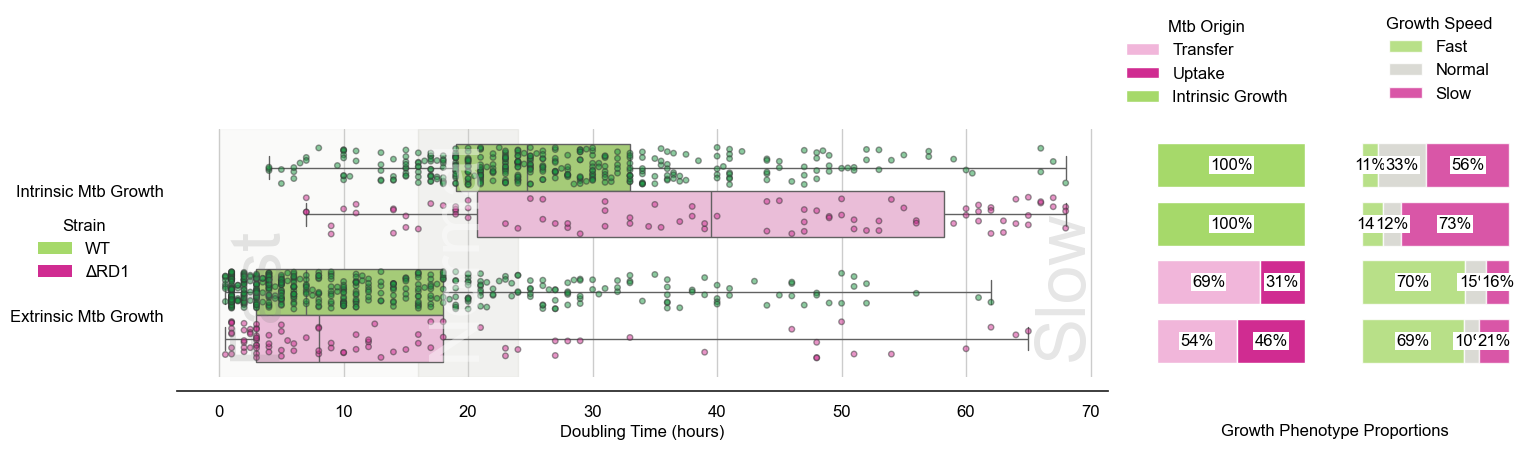

In [9]:
# Update the labels in the dataframe
subset_df['Growth'] = subset_df.apply(
    lambda row: "Intrinsic Mtb Growth" if row['mtb_origin'] == 'Growth'
                else "Extrinsic Mtb Growth",
    axis=1
)

# Update the order variable to group intrinsic growth categories next to each other
order = ["Intrinsic Mtb Growth" , "Extrinsic Mtb Growth"]


# Use the new order in your plots
fig = plt.figure(figsize=(width_in * 1.4, height_in * 1.4))  # Adjust dimensions as needed
gs = gridspec.GridSpec(1, 3, width_ratios=[6, 1, 1])

# First subplot: Boxplot and stripplot
ax1 = plt.subplot(gs[0])
sns.boxplot(
    data=subset_df, x="Doubling Times", y="Growth", hue="Strain", 
    whis=[0, 100], width=.75, palette=[expanded_piyg[1], expanded_piyg[-2]], order=order, ax=ax1
)
sns.stripplot(
    data=subset_df, x="Doubling Times", y="Growth", size=4, hue="Strain", 
    palette=[expanded_piyg[0], expanded_piyg[-1]], alpha=0.5, order=order, 
    edgecolor='auto', linewidth=1, jitter=0.3, ax=ax1, dodge =True
)

# Add shaded regions for doubling time categories
ax1.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0.1, label='Fast (<20h)')
ax1.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.3, label='Normal (20-28h)')
ax1.axvspan(bins[3], 70, color=expanded_piyg[3], alpha=0.1, label='Slow (>28h)')

# Add vertical text labels within each category region
ax1.text(0.5, 1.25, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax1.text(16.5, 1.25, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax1.text(70.5, 1.25, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

# Final tweaks for boxplot
ax1.xaxis.grid(True)
sns.despine(offset=10, left=True)
ax1.legend_.remove()
ax1.set_xlabel('Doubling Time (hours)')
ax1.set_ylabel('')

# Create legend handles and add a new legend
handles = [
    Patch(facecolor=expanded_piyg[1], edgecolor='none', label='WT'),
    Patch(facecolor=expanded_piyg[-1], edgecolor='none', label='ΔRD1')
]
ax1.legend(
    handles=handles, title='Strain', loc='upper center',
    bbox_to_anchor=(-0.1, 0.7), frameon=False, fontsize=14
)


# Step 2: Create an additional subplot for the normalized bar chart
ax2 = plt.subplot(gs[1], sharey = ax2, frame_on=False)  # Share y-axis with ax1 for alignment

# Data setup for intrinsic and extrinsic grouping
origin_counts = subset_df.groupby(['Growth', 'Strain', 'mtb_origin']).size().unstack(level=1).fillna(0)
extrinsic_proportions = origin_counts.T['Extrinsic Mtb Growth']
extrinsic_proportions = extrinsic_proportions.div(extrinsic_proportions.sum(axis=1), axis=0)


# Intrinsic proportions (100% Growth for Wild-Type and RD1)
intrinsic_proportions = pd.DataFrame(
    [1.0, 1.0], index=extrinsic_proportions.index, columns=['Growth']
)

# Reversed order for plotting: RD1 Extrinsic, WT Extrinsic, RD1 Intrinsic, WT Intrinsic
plot_order = [
    ('Extrinsic Growth', 'RD1'),
    ('Extrinsic Growth', 'WT'),
    ('Intrinsic Growth', 'RD1'),
    ('Intrinsic Growth', 'WT')
]

# Prepare data for plotting
plot_data = {
    ('Intrinsic Growth', 'WT'): intrinsic_proportions.loc['WT', 'Growth'],
    ('Intrinsic Growth', 'RD1'): intrinsic_proportions.loc['RD1', 'Growth'],
    ('Extrinsic Growth', 'WT'): extrinsic_proportions.loc['WT', ['Transfer', 'Uptake']].sum(),
    ('Extrinsic Growth', 'RD1'): extrinsic_proportions.loc['RD1', ['Transfer', 'Uptake']].sum(),
}
categories = ['Intrinsic Growth', 'Extrinsic Growth']
strains = ['WT', 'RD1']

# Plot setup
bar_width = 0.75
x_positions = range(len(plot_order)) #np.linspace(-0.15, 1.65, 5)  # Spaced positions for bars

# Track whether labels are added to avoid duplicates in the legend
labels_added = set()

# Plot bars for the specified order
for i, (growth_type, strain) in enumerate(plot_order):
    if growth_type == 'Intrinsic Growth':
        # Plot Intrinsic Growth bars
        label = "Intrinsic Growth" if "Intrinsic Growth" not in labels_added else None
        bar = ax2.barh(
            x_positions[i], plot_data[(growth_type, strain)], height=bar_width,
            label=label, color=expanded_piyg[1]
        )
        # Overlay percentage
        percentage = f"{round(plot_data[(growth_type, strain)] * 100):d}%"
        ax2.text(
            plot_data[(growth_type, strain)] / 2, x_positions[i], percentage,
            ha='center', va='center', fontsize=14, color='black',
            bbox=dict(facecolor='white', edgecolor='none', pad=1)
        )
        labels_added.add("Intrinsic Growth")
    elif growth_type == 'Extrinsic Growth':
        # Plot stacked Extrinsic Growth bars
        bottom = 0
        for category, color in zip(['Transfer', 'Uptake'], [expanded_piyg[-2], expanded_piyg[-1]]):
            label = f"{category}" if category not in labels_added else None
            bar = ax2.barh(
                x_positions[i], extrinsic_proportions.loc[strain, category], height=bar_width,
                left=bottom, label=label, color=color
            )
            percentage = f"{round(extrinsic_proportions.loc[strain, category] * 100):d}%"
            ax2.text(
                bottom + extrinsic_proportions.loc[strain, category] / 2, x_positions[i], percentage,
                ha='center', va='center', fontsize=14, color='black',
                bbox=dict(facecolor='white', edgecolor='none', pad=1)
            )
            bottom += extrinsic_proportions.loc[strain, category]
            labels_added.add(category)

# Add labels, legend, and formatting for ax2
ax2.set_yticks(range(len(plot_order)))
ax2.set_yticklabels([f"{growth} {strain}" for growth, strain in plot_order], fontsize=10)
ax2.set_xlabel('')
ax2.set_xticks([])
# Add legend for clarity
ax2.legend(title='Mtb Origin', loc='upper left', bbox_to_anchor=(-0.3, 1.5), frameon=False)

# Adjust layout for clarity
sns.despine(ax=ax2, offset=10, left=True, right=True)

# Step 2: Add the new plot
ax3 = plt.subplot(gs[2], sharey=ax2, frame_on=False)  # New subplot shares y-axis for alignment

# Step 3: Prepare data for the new plot
# Example: Growth speed proportions within each Growth category
growth_speed_counts = subset_df.groupby(['Growth','Strain', 'Growth Category'], observed=False).size().unstack(fill_value=0)
growth_speed_percentages = growth_speed_counts.div(growth_speed_counts.sum(axis=1), axis=0)

# Plot the new proportions as a stacked horizontal bar chart
growth_speed_percentages.plot(
    kind='barh',
    stacked=True,
    ax=ax3,
    color=[expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]],
    alpha=0.8, width = bar_width
)

# Step 4: Customize the new plot
ax3.set_xlabel('Proportion of Growth Speeds')  # Add label for proportions
# ax3.set_xlim(0, 1)  # Ensure proportions range from 0 to 1
ax3.set_ylabel('')
ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax3.set_xlabel('')
sns.despine(ax=ax3, offset=10, left=True, right=True)  # Clean up spines
ax3.legend(title='Growth Speed', loc='lower center', bbox_to_anchor=(0.5, 1.05), frameon=False)  # Place legend
for container in ax3.containers:
    for bar in container:
        width = bar.get_width()  # Get the width of the current bar
        if width > 0:  # Only add labels for non-zero bars
            x = bar.get_x() + width / 2  # Position at the center of the bar
            y = bar.get_y() + bar.get_height() / 2  # Center vertically
            percentage = f"{round(width * 100):d}%"  # Format percentage rounded to an integer
            ax3.text(x, y, percentage, ha='center', va='center', fontsize=14, color='black', bbox=dict(facecolor='white', edgecolor='none', pad=1)
)

sns.despine(offset=10, left=True)
fig.text(0.87, 0.04, 'Growth Phenotype Proportions', ha='center', fontsize=14)  # Shared x-axis label


plt.tight_layout()
# plt.savefig('/mnt/SYNO/macrohet_syno/results/manuscript/f3/f3_boxplot.pdf', bbox_inches='tight', dpi=314)
plt.show()


In [10]:
# Define common font settings
font_settings = dict(
    family='Helvetica, Arial, sans-serif',
    size=16, 
    color='black'
)

In [207]:
expanded_piyg[3]

'#d1d1ca'

/tmp/ipykernel_320931/1823788225.py:73: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



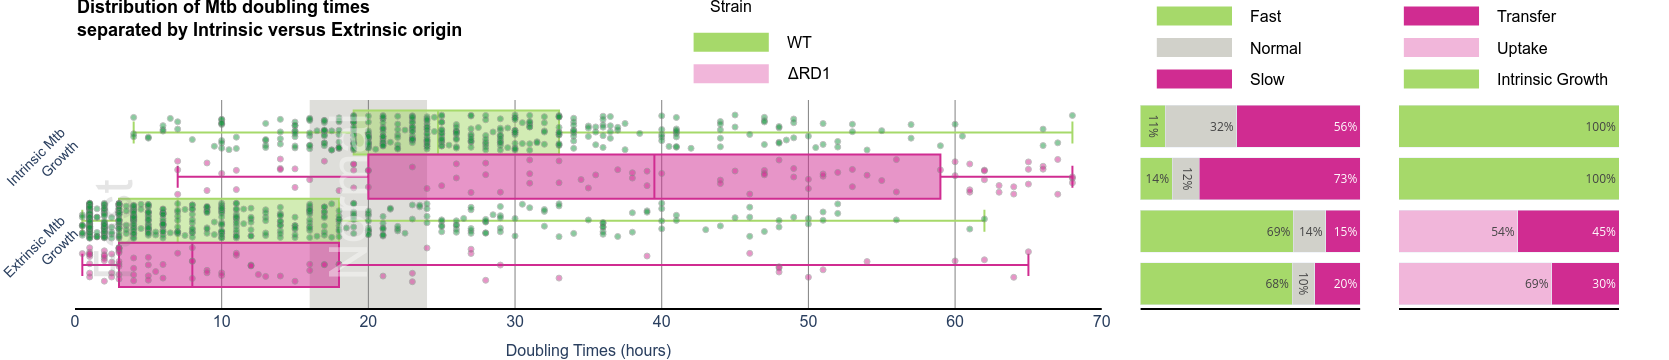

In [198]:
 # Adjust y-positions for better separation
positions = {
    ('Intrinsic Mtb Growth', 'WT'): 3,
    ('Intrinsic Mtb Growth', 'RD1'): 2,
    ('Extrinsic Mtb Growth', 'WT'): 1,
    ('Extrinsic Mtb Growth', 'RD1'): 0
}

fig = make_subplots(rows=1, cols=3, column_widths=[0.7, 0.15, 0.15], horizontal_spacing=0.025)

# Main plot with adjusted positions
for growth in ['Intrinsic Mtb Growth', 'Extrinsic Mtb Growth']:
    for strain in subset_df['Strain'].unique():
        data = subset_df[(subset_df['Growth'] == growth) & (subset_df['Strain'] == strain)]
        y_pos = positions[(growth, strain)]
        
        # Box plot
        fig.add_trace(
            go.Box(
                x=data['Doubling Times'],
                y=[y_pos] * len(data),
                name=f"{growth} - {strain}",
                marker_color=expanded_piyg[1] if strain == 'WT' else expanded_piyg[-1],
                showlegend=False,
                orientation='h',
                boxpoints=False, width = 1
            ), row=1, col=1
        )
        
        # Strip plot with jitter
        jitter = np.random.uniform(-0.4, 0.4, len(data))
        fig.add_trace(
            go.Scatter(
                x=data['Doubling Times'],
                y=[y_pos + j for j in jitter],
                mode='markers',
                customdata=data['Video Link'],
                hoverinfo="text",
                text=[
                    f"<b>Doubling Time:</b> {x:.2f}<br><b>Phenotype:</b> {growth}<br><b>Strain:</b> {strain}<br>"
                    for x in data['Doubling Times']],
                marker=dict(
                    color=expanded_piyg[0] if strain == 'WT' else expanded_piyg[-1],
                    size=6,
                    opacity=0.5,
                    line=dict(color='gray', width=1)
                ),
                showlegend=False
            ), row=1, col=1
        )

# Update layout with new y-axis settings
fig.update_layout(
    yaxis=dict(
        ticktext=['Extrinsic Mtb<br>Growth', 'Intrinsic Mtb<br>Growth', ],#'ΔRD1', 'WT'],
        tickvals=[0.75,2.75],
        tickmode='array', tickangle=360-45, 
        tickfont=dict(size=14, family='Helvetica'),
        title_font=dict(size=14, family='Helvetica'),
    )
)
bin_start, bin_end = bins[1], bins[2]
fig.add_vrect(
    x0=bin_start, x1=bin_end,
    fillcolor=expanded_piyg[3],
    opacity=0.7,
    layer='below',
    line_width=0,
    row=1, col=1
)

# First proportion plot (Growth Speed)
growth_speed_data = subset_df.groupby(['Growth', 'Strain', 'Growth Category']).size().unstack(fill_value=0)
growth_speed_pcts = growth_speed_data.div(growth_speed_data.sum(axis=1), axis=0)

for i, ((growth, strain), row) in enumerate(growth_speed_pcts.iterrows()):  # Unpacking multi-index
    for j, (category, color) in enumerate(zip(['Fast', 'Normal', 'Slow'], 
                                              [expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]])):
        percentage = row[category]  # Extract the percentage value

        if percentage > 0:
            fig.add_trace(
                go.Bar(
                    x=[percentage],  # Keep the bar size proportional
                    y=[i],  # Position in y-axis
                    orientation='h',
                    marker_color=color,
                    name=category,
                    text=[f"{int(percentage * 100)}%"],  # Display percentage inside the bar
                    textposition='inside',
                    hoverinfo="text",
                    hovertext=[f"<b>Strain:</b> {strain}<br><b>Category:</b> {category}<br><b>Percentage:</b> {round(percentage * 100, 2)}%"],  # Proper hover text
                    showlegend=(i == 0)  # Only show legend once per category
                ), row=1, col=2
            )

for i, (growth, strain) in enumerate([
    ('Extrinsic Mtb Growth', 'WT'), 
    ('Extrinsic Mtb Growth', 'RD1'),
    ('Intrinsic Mtb Growth', 'WT'),
    ('Intrinsic Mtb Growth', 'RD1'),
]):
    if growth == 'Intrinsic Mtb Growth':
        fig.add_trace(
            go.Bar(
                x=[1.0],
                y=[i],
                orientation='h',
                marker_color=expanded_piyg[1] if strain == 'WT' else expanded_piyg[1],
                name="Intrinsic Growth",
                text=['100%'],  # Keeps text inside bars
                textposition='inside',
                hoverinfo="text",
                hovertext=[f"<b>Strain:</b> {strain}<br><b>Origin:</b> Intrinsic Growth<br><b>Percentage:</b> 100%"],  # Hover text
                showlegend=False
            ), row=1, col=3
        )
    else:
        data = extrinsic_proportions.loc[strain]  # Extract data from table
        fig.add_trace(
            go.Bar(
                x=[data['Transfer']],
                y=[i],
                orientation='h',
                marker_color=expanded_piyg[-2],
                name="Transfer",
                showlegend=(i == 0),
                text=[f"{int(data['Transfer'] * 100)}%"],  # Display inside bar
                textposition='inside',
                hoverinfo="text",
                hovertext=[f"<b>Strain:</b> {strain}<br><b>Origin:</b> Transfer<br><b>Percentage:</b> {round(data['Transfer'] * 100, 2)}%"]
            ), row=1, col=3
        )
        fig.add_trace(
            go.Bar(
                x=[data['Uptake']],
                y=[i],
                orientation='h',
                marker_color=expanded_piyg[-1],
                name="Uptake",
                showlegend=(i == 0),
                text=[f"{int(data['Uptake'] * 100)}%"],
                textposition='inside',
                hoverinfo="text",
                hovertext=[f"<b>Strain:</b> {strain}<br><b>Origin:</b> Uptake<br><b>Percentage:</b> {round(data['Uptake'] * 100, 2)}%"]
            ), row=1, col=3
        )


# Update axes for proportion plots
fig.update_xaxes(range=[0, 1], showticklabels=False, row=1, col=2)
fig.update_xaxes(range=[0, 1], showticklabels=False, row=1, col=3)
fig.update_yaxes(range=[0, 1], showticklabels=False, row=1, col=2)
fig.update_yaxes(range=[0, 1], showticklabels=False, row=1, col=3)



# Remove all existing legends
fig.update_traces(showlegend=False)

# Add legend annotations above second plot (Growth Speed)
for i, (category, color) in enumerate(zip(['Fast', 'Normal', 'Slow'], 
                        [expanded_piyg[1], expanded_piyg[3], expanded_piyg[5]])):
    fig.add_shape(
        type="rect",
        x0=0.7, x1=0.75,
        y0=1.35 - (i*0.15), y1=1.45 - (i*0.15),
        xref="paper", yref="paper",
        fillcolor=color,
        line_color="white",
    )
    fig.add_annotation(
        x=0.76, y=1.4 - (i*0.15),
        text=category,
        xref="paper", yref="paper",
        showarrow=False,
        font=font_settings,
        xanchor='left',  # 'left', 'center', or 'right'
        yanchor='middle'  # 'top', 'middle', or 'bottom'
    )

# Add legend annotations above third plot (Transfer/Uptake)
colors = [expanded_piyg[-1], expanded_piyg[-2], expanded_piyg[1]]
for i, label in enumerate(['Transfer', 'Uptake', 'Intrinsic Growth']):
    fig.add_shape(
        type="rect",
        x0=0.86, x1=0.91,
        y0=1.35 - (i*0.15), y1=1.45 - (i*0.15),
        xref="paper", yref="paper",
        fillcolor=colors[i],
        line_color="white",
    )
    fig.add_annotation(
        x=0.92, y=1.4 - (i*0.15),
        text=label,
        xref="paper", yref="paper",
        showarrow=False,
        font=font_settings,
        xanchor='left',  # 'left', 'center', or 'right'
        yanchor='middle'  # 'top', 'middle', or 'bottom'
    )
# Add titles above legends
fig.add_annotation(
   x=0.725, y=1.55,
   text="Growth Speed",
   xref="paper", yref="paper",
   showarrow=False,
    font=font_settings,
   xanchor='left',
   yanchor='middle'
)

fig.add_annotation(
   x=0.9, y=1.55,
   text="Mtb Origin",
   xref="paper", yref="paper",
   showarrow=False,
    font=font_settings,
   xanchor='left',
   yanchor='middle'  
)

# fig.add_annotation(
#    x=0.8, y=-0.2,
#    text="Growth Phenotype<br>Proportions",
#    xref="paper", yref="paper",
#    showarrow=False,
#         font=font_settings,
#    xanchor='left',
#    yanchor='middle'  
# )



# Add vertical text labels within each category region
fig.add_annotation(x=bins[0] + 0.5, y=-0.4, text='Fast', font=dict(family='Helvetica', size=52, color='gray', ), opacity=0.2, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=bins[1] + 0.5, y=-0.4, text='Normal', font=dict(family='Helvetica', size=52, color='white'), opacity=0.4, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=70 + 0.5, y=-0.4, text='Slow', font=dict(family='Helvetica', size=52, color='gray'), opacity=0.2, 
                  xanchor='right', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
# Add legend for strains
colors = [expanded_piyg[1], expanded_piyg[-2]]  # WT and RD1 colors
for i, (label, color) in enumerate(zip(['WT', 'ΔRD1'], colors)):
   fig.add_shape(
       type="rect",
       x0=0.4, x1=0.45,
       y0=1.225 - (i*0.15), y1=1.325 - (i*0.15),
       xref="paper", yref="paper",
       fillcolor=color,
       line_color="white",
   )
   fig.add_annotation(
       x=0.46, y=1.275 - (i*0.15),
       text=label,
       xref="paper", yref="paper",
       showarrow=False,
        font=font_settings,
       xanchor='left',
       yanchor='middle'
   )
fig.add_annotation(
   x=0.425, y=1.45,
   text="Strain",
   xref="paper", yref="paper",
   showarrow=False,
        font=font_settings,
   xanchor='center',
   yanchor='middle'
    )
fig.add_annotation(
   x=0.0, y=1.5,
   text="<b>Distribution of Mtb doubling times<br>separated by Intrinsic versus Extrinsic origin</br>",
   xref="paper", yref="paper",
   showarrow=False,
   font=dict(
       family='Helvetica, Arial, sans-serif',
       size=18, 
       color='black'
   ),
   align='left'
)


# Add horizontal lines
for col, x_range in [(2, (0, 1)),(3, (0, 1))]:
    fig.add_shape(
        type='line',
        x0=x_range[0], x1=x_range[1],
        y0=-0.5, y1=-0.5,
        line=dict(color='black', width=4),
        row=1, col=col
    )
# Add horizontal lines
for col, x_range in [(1, (-2, 72))]:
    fig.add_shape(
        type='line',
        x0=x_range[0], x1=x_range[1],
        y0=-1, y1=-1,
        line=dict(color='black', width=2),
        row=1, col=col
    )


fig.update_xaxes(
   showgrid=True,
   gridwidth=1,
   gridcolor='grey',
   row=1, col=1,
    title_text="Doubling Times (hours)", 
    title_font=dict(size=16, family="Helvetica"),
    tickfont=dict(size=16, family="Helvetica"),  # Change x-tick font and size
    tickmode="linear",  # Ensure evenly spaced ticks
    tick0=0,  # Start at 0
    dtick=10,  # Interval of 10
    range=[0, 70],  # Ensure range covers 0 to 70
)

# Update layout for proper stacking
fig.update_layout(
    barmode='stack',
    width=1200,  # Increase width
    height=300,  # Increase height
    margin=dict(l=0, r=50, t=100, b=50),  # Adjust margins for better spacing    yaxis1=dict(range=[-0.5, 3.5]),
    yaxis2=dict(range=[-0.5, 3.5]),
    yaxis3=dict(range=[-0.5, 3.5]),
    plot_bgcolor='white',
   paper_bgcolor='white'
)

fig.show()

boxplot=fig

In [199]:
# Convert figure to JSON string with indentation for readability
fig_json = fig.to_json(pretty=True)

# Save JSON to a file
with open("/home/dayn/analysis/macrohetest/docs/figures/data/F3D_plot_data.json", "w") as f:
    f.write(fig_json)

# Add sankey

In [99]:
df = df[df['Strain'] != 'UNI']

In [100]:
df = df[df['Experiment ID'] != 'ND0004']

In [101]:
df

,ID,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Video Link,Image Link
251,1.3.3.ND0003,0.0,0.000000,0.000000,469.429446,202.767597,NaN,False,False,42.471859,...,NaN,NaN,NaN,NaN,None,None,None,1.0,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
252,1.3.3.ND0003,0.5,0.000000,0.000000,528.854007,202.767597,NaN,False,False,34.811165,...,0.000000,NaN,NaN,NaN,None,None,None,1.0,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
253,1.3.3.ND0003,1.0,0.000000,0.000000,537.145286,202.767597,NaN,False,False,33.768791,...,0.000000,NaN,NaN,NaN,None,None,None,1.0,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
254,1.3.3.ND0003,1.5,0.000000,0.000000,701.920497,202.767597,NaN,False,False,38.236599,...,0.000000,NaN,NaN,NaN,None,None,None,1.0,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
255,1.3.3.ND0003,2.0,0.000000,0.000000,612.839527,202.767597,False,False,False,32.407787,...,0.000000,NaN,0.0,0.0,None,None,None,1.0,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1092540,998.5.5.ND0003,48.0,0.000000,-0.111742,813.037051,-539.871799,NaN,False,False,868.403076,...,0.000000,0.0,NaN,NaN,None,None,None,0.78,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
1092541,998.5.5.ND0003,48.5,0.000000,-0.111742,745.745831,-539.871799,NaN,False,False,868.194641,...,0.000000,0.0,NaN,NaN,None,None,None,0.78,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
1092542,998.5.5.ND0003,49.0,0.000000,-0.111742,668.219016,-539.871799,NaN,False,False,872.108582,...,0.000000,0.0,NaN,NaN,None,None,None,0.78,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...
1092543,998.5.5.ND0003,49.5,0.000000,-0.111742,662.609552,-539.871799,NaN,False,False,871.521606,...,0.000000,0.0,NaN,NaN,None,None,None,0.78,https://s3.eu-west-2.amazonaws.com/macrohet.gl...,https://s3.eu-west-2.amazonaws.com/macrohet.gl...


In [106]:
unique_combinations = df[['Strain', 'Compound', 'Concentration']].drop_duplicates()

In [107]:
unique_combinations

,Strain,Compound,Concentration
251,WT,CTRL,EC0
478,WT,INH,EC99
551,WT,RIF,EC99
709,RD1,INH,EC50
934,WT,INH,EC50
1182,WT,PZA,EC50
1332,WT,RIF,EC50
1891,RD1,INH,EC99
2150,RD1,CTRL,EC0
2820,RD1,PZA,EC50


In [108]:
# Initialize a list to store data for each combination
sankey_data_list = []

# Loop through each combination
for idx, row in tqdm(unique_combinations.iterrows()):
    
    strain = row['Strain']
    compound = row['Compound']
    concentration = row['Concentration']
    if strain == 'UNI':
        continue
    # if concentration != 'EC0':
    #     continue
    print(strain, compound, concentration)
    
    subset_df = df[(df['Strain'] == strain)
                     & (df['Compound'] == compound)
                     & (df['Concentration'] == concentration)
                     ]
    subset_df.drop_duplicates('ID', inplace=True)
    
    # Identify transitions
    transitions = subset_df.groupby(['Initial Infection Status', 'Final Infection Status'])['ID'].apply(list).reset_index()
    
    # Initialize counts
    N_stayed_infected = 0
    N_got_uninfected = 0
    N_got_infected = 0
    N_stayed_uninfected = 0
    
    # Extract counts safely (some combinations might be missing)
    for _, t_row in transitions.iterrows():
        initial_status = t_row['Initial Infection Status']
        final_status = t_row['Final Infection Status']
        ids = t_row['ID']
        count = len(ids)
        if initial_status == 1 and final_status == 1:
            N_stayed_infected = count
        elif initial_status == 1 and final_status == 0:
            N_got_uninfected = count
        elif initial_status == 0 and final_status == 1:
            N_got_infected = count
        elif initial_status == 0 and final_status == 0:
            N_stayed_uninfected = count
    
    # Count the intermediate transitions for 'got infected' cells
    infected_ids = transitions[(transitions['Initial Infection Status'] == 0) & (transitions['Final Infection Status'] == 1)]['ID']
    if not infected_ids.empty:
        infected_ids = infected_ids.values[0]
        infected_subset_df = subset_df[subset_df['ID'].isin(infected_ids)]
        
        N_uptake = infected_subset_df['mtb_origin'].value_counts().get('Uptake', 0)
        N_transfer = infected_subset_df['mtb_origin'].value_counts().get('Transfer', 0)
        N_unknown = infected_subset_df['mtb_origin'].value_counts().get('Unknown', 0)
        N_junk = infected_subset_df['mtb_origin'].value_counts().get('Junk', 0)
    else:
        N_uptake = N_transfer = N_unknown = N_junk = 0
    
    # Adjust N_got_infected
    N_got_infected -= (N_uptake + N_transfer + N_unknown + N_junk)
    
    # Prepare the data for the Sankey diagram
    sankey_data = {
        'strain': strain,
        'compound': compound,
        'concentration': concentration,
        'N_stayed_infected': N_stayed_infected,
        'N_got_uninfected': N_got_uninfected,
        'N_got_infected': N_got_infected,
        'N_stayed_uninfected': N_stayed_uninfected,
        'N_uptake': N_uptake,
        'N_transfer': N_transfer,
        'N_unknown': N_unknown,
        'N_junk': N_junk
    }
    sankey_data_list.append(sankey_data)

0it [00:00, ?it/s]

WT CTRL EC0
WT INH EC99
WT RIF EC99
RD1 INH EC50
WT INH EC50
WT PZA EC50
WT RIF EC50
RD1 INH EC99
RD1 CTRL EC0
RD1 PZA EC50
RD1 PZA EC99
RD1 RIF EC99
RD1 RIF EC50
WT PZA EC99


In [109]:
# Calculate total counts and find the maximum total
max_total = 0
for data in sankey_data_list:
    total = sum([data[key] for key in ['N_stayed_infected', 'N_got_uninfected', 'N_got_infected', 'N_stayed_uninfected', 'N_uptake', 'N_transfer']])
    data['total'] = total
    if total > max_total:
        max_total = total

In [110]:
data['strain']

'WT'

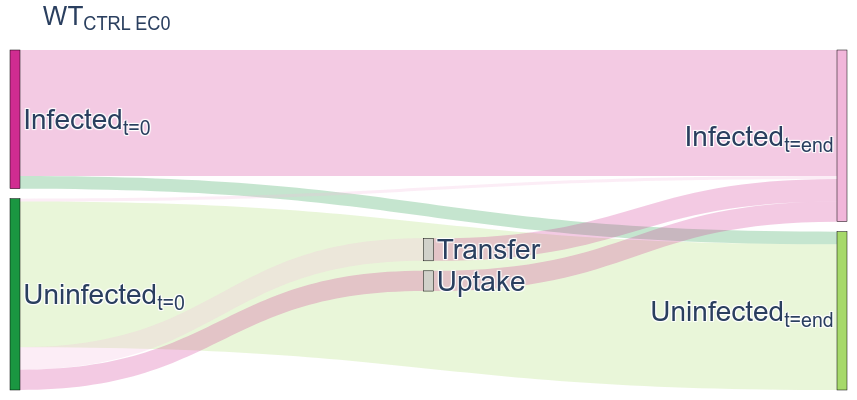

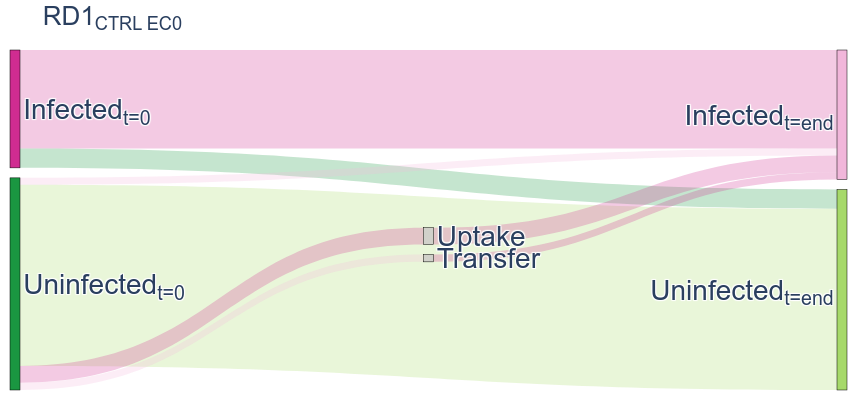

In [111]:
# Define labels and colors (unchanged)
labels = [
    "Infected<sub>t=0</sub>",          # Infected with subscript t=0
    "Uninfected<sub>t=0</sub>",       # Uninfected with subscript t=0
    "Infected<sub>t=end</sub>",        # Infected with subscript t=end
    "Uninfected<sub>t=end</sub>",      # Uninfected with subscript t=end
    "Uptake",                          # Uptake
    "Transfer"                         # Transfer
]

node_colors = [colours.expanded_piyg[i] for i in [-1, 0, -2, 1, 3, 3]]
link_colors = [
    f'rgba({int(color[1:3], 16)}, {int(color[3:5], 16)}, {int(color[5:7], 16)}, 0.25)'
    for color in [colours.expanded_piyg[i] for i in [-1, 0, -2, 1, -1, -2, -1, -1]]
]
sankeys = {}
# Loop through each sankey_data and create a separate Sankey diagram for each
for idx, data in enumerate(sankey_data_list):
    strain = data['strain'] 
    conc = data['concentration']
    if conc != 'EC0':
        continue
    if strain not in ['WT', 'RD1']:
        continue
    

    fig = go.Figure()

    # Normalize values
    normalization_factor = data['total'] / max_total
    N_stayed_infected = data['N_stayed_infected'] / normalization_factor
    N_got_uninfected = data['N_got_uninfected'] / normalization_factor
    N_got_infected = data['N_got_infected'] / normalization_factor
    N_stayed_uninfected = data['N_stayed_uninfected'] / normalization_factor
    N_uptake = data['N_uptake'] / normalization_factor
    N_transfer = data['N_transfer'] / normalization_factor
    
    # Create value list
    value = [
        N_stayed_infected,     # Initially Infected -> Finally Infected
        N_got_uninfected,      # Initially Infected -> Finally Uninfected
        N_got_infected,        # Initially Uninfected -> Finally Infected
        N_stayed_uninfected,   # Initially Uninfected -> Finally Uninfected
        N_uptake,              # Initially Uninfected -> Uptake
        N_transfer,            # Initially Uninfected -> Transfer
        N_uptake,              # Uptake -> Finally Infected
        N_transfer,            # Transfer -> Finally Infected
    ]
    
    # Ensure no negative or NaN values
    value = [max(v, 0) if not pd.isnull(v) else 0 for v in value]
    
    # Define source and target arrays
    source = [0, 0, 1, 1, 1, 1, 4, 5]
    target = [2, 3, 2, 3, 4, 5, 2, 2]
    
    # Create the Sankey diagram
    sankey = go.Sankey(
        domain=dict(x=[0, 1], y=[0, 1]),
        orientation='h',
        node=dict(
            pad=10,
            thickness=10,
            line=dict(color="black", width=0.5),
            label=labels,
            color=node_colors,
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_colors
        ),
        textfont=dict(size=28)
    )
    
    # Add the Sankey diagram to the figure
    fig.add_trace(sankey)

    # Update layout for each figure
    fig.update_layout(
    title_text=f"{data['strain']}<sub>{data['compound']} {data['concentration']}</sub>",
        width=400,  # Adjust as needed
        height=400,  # Adjust as needed
        font_family="Helvetica",
        margin=dict(l=10, r=10, t=50, b=10),
        titlefont=dict(size=26)
    )

    # # Save each figure with a unique filename
    # fig.write_image(f'{syno_base_dir()}/results/sankey/sankey_diagram_{data["strain"]}_{data["compound"]}_{data["concentration"]}.pdf')
    sankeys[strain] = fig
    # fig.write_html(f'../interactive_plots/sankey_diagram_{data["strain"]}_{data["compound"]}_{data["concentration"]}.html')
    # Display each figure
    fig.show()

# output json

In [113]:
strain

'WT'

In [20]:
import json
import numpy as np

def is_numeric(x):
    """Check if a value is numeric and can be tested for NaN"""
    return isinstance(x, (int, float, np.integer, np.floating))

def convert_to_serializable(obj):
    """
    Recursively convert non-serializable objects to serializable types,
    handling NaN values properly
    """
    if isinstance(obj, np.ndarray):
        # Handle arrays depending on their dtype
        if np.issubdtype(obj.dtype, np.number):
            return [None if (is_numeric(x) and np.isnan(x)) else x 
                   for x in obj.tolist()]
        return obj.tolist()
    
    elif isinstance(obj, (np.integer, np.floating)):
        if np.isnan(obj):
            return None
        return float(obj)
    
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    
    elif hasattr(obj, 'to_plotly_json'):
        return convert_to_serializable(obj.to_plotly_json())
    
    # Handle other numeric types that might be NaN
    elif is_numeric(obj):
        if np.isnan(obj):
            return None
        return float(obj) if isinstance(obj, (np.integer, np.floating)) else obj
    
    return obj

def export_figure_to_json(fig, output_path):
    """
    Export a single figure to JSON with proper NaN handling
    """
    figure_data = {
        'data': [],
        'layout': convert_to_serializable(fig.layout)
    }
    
    for trace in fig.data:
        converted_trace = convert_to_serializable(trace)
        figure_data['data'].append(converted_trace)
        
    with open(output_path, 'w') as f:
        json.dump(figure_data, f, indent=2)

# # Export each subplot
# for i in range(3):  # For subplots A, B, and C
#     output_path = f'../docs/figures/data/F3{chr(65+i)}_plot_data.json'
#     export_figure_to_json(sc_figs[i], output_path)

# Export the boxplot
export_figure_to_json(boxplot, '../docs/figures/data/F3D_plot_data.json')

# for i, strain in zip(range(2), ['WT', 'RD1']):  # For subplots A, B, and C
#     output_path = f'../docs/figures/data/F3{chr(69+i)}_plot_data.json'
#     export_figure_to_json(sankeys[strain], output_path)

In [119]:
# Create the HTML template
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        /* Main layout containers */
        .main-container {{
            width: 1000px;
            margin: 0 auto;
            padding: 20px;
        }}
        
        /* Growth curves section */
        .pairs-container {{
            display: flex;
            flex-direction: column;
            margin-bottom: 40px;
        }}
        
        .pair {{
            display: flex;
            gap: 40px;
            align-items: center;
        }}
        
        /* Images */
        .figure-image {{
            flex: 0 0 auto;
            width: 50%;
            position: relative;
        }}
        
        .figure-image img {{
            width: 100%;
            height: auto;
            cursor: pointer;
        }}
        
        /* Plots */
        .growth-plot {{
            flex: 1;
            min-width: 0;
        }}
        
        /* Boxplot section */
        .boxplot-section {{
            display: flex;
            gap: 0px;
            align-items: flex-start;

        }}
        
        .caption-image {{
            width: 35px;
            flex: 0 0 auto;
        }}
        
        #boxplot {{
            flex: 1;
        }}
        
        /* Hover effects */
        .hover-content, .hover-popup, .video-hover {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        
        .hover-content {{
            display: flex;
            align-items: center;
        }}
        
        .hover-content img {{
            width: 300px;
            height: auto;
        }}
        
        .hover-popup, .video-hover {{
            display: none;
        }}
        
    </style>
</head>
<body>
<div class="main-container">
   <!-- Growth Curves Section -->
   <div class="pairs-container">
       <!-- Pair 1 -->
       <div class="pair">
           <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S2.mp4">
               <img src="../images/Figure_2_1.png" alt="Figure 1">
               <div class="video-hover">
                   <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                          autoplay loop muted playsinline></video>
               </div>
           </div>
           <div id="growth-plot-1" class="growth-plot"></div>
       </div>
       
       <!-- Pair 2 -->
       <div class="pair">
           <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S3.mp4">
               <img src="../images/Figure_2_2.png" alt="Figure 2">
               <div class="video-hover">
                   <video style="width: 400px; height: 400px; object-fit: cover;" 
                          autoplay loop muted playsinline></video>
               </div>
           </div>
           <div id="growth-plot-2" class="growth-plot"></div>
       </div>
       
       <!-- Pair 3 -->
       <div class="pair">
           <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S4.mp4">
               <img src="../images/Figure_2_3.png" alt="Figure 3">
               <div class="video-hover">
                   <video style="width: 400px; height: 400px; object-fit: cover;" 
                          autoplay loop muted playsinline></video>
               </div>
           </div>
           <div id="growth-plot-3" class="growth-plot"></div>
       </div>
   </div>
   
   <!-- Boxplot Section -->
   <div class="boxplot-section">
       <div class="caption-image">
           <img src="../images/D_caption.png" style="width: 100%; height: 80%; object-fit: cover; object-position: top; margin-left: -10px;" alt="Caption">
       </div>
       <div id="boxplot"></div>
       <div id="hover-popup" class="hover-popup">
           <video id="popup-video" style="width: 400px; height: 400px; object-fit: cover;" 
                  autoplay loop muted playsinline></video>
       </div>
   </div>
   
   <!-- Sankey Plots -->
   <div style="display: flex; justify-content: center; gap: 20px; margin-top: 40px;">
       <div id="sankey-wt" style="flex: 1; max-width: 450px;"></div>
       <div id="sankey-rd1" style="flex: 1; max-width: 450px;"></div>
   </div>
</div>
    
    <script>
        // Growth curves plots
        const growthFig1 = {sc_figs[0].to_json()};
        const growthFig2 = {sc_figs[1].to_json()};
        const growthFig3 = {sc_figs[2].to_json()};
        const boxplotFig = {boxplot.to_json()};
        const sankeyWT = {sankeys['WT'].to_json()};
        const sankeyRD1 = {sankeys['RD1'].to_json()};
        
        
        // Initialize all plots with minimal margins
        const layout1 = {{...growthFig1.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout2 = {{...growthFig2.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout3 = {{...growthFig3.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        
        Plotly.newPlot('growth-plot-1', growthFig1.data, layout1);
        Plotly.newPlot('growth-plot-2', growthFig2.data, layout2);
        Plotly.newPlot('growth-plot-3', growthFig3.data, layout3);
        Plotly.newPlot('boxplot', boxplotFig.data, boxplotFig.layout);
        Plotly.newPlot('sankey-wt', sankeyWT.data, sankeyWT.layout);
        Plotly.newPlot('sankey-rd1', sankeyRD1.data, sankeyRD1.layout);
        
        // Setup hover for growth plots
        ['growth-plot-1', 'growth-plot-2', 'growth-plot-3'].forEach(plotId => {{
            const plotDiv = document.getElementById(plotId);
            plotDiv.style.position = 'relative';  // Make plot div a positioning context
            
            plotDiv.on('plotly_hover', function(eventData) {{
                const point = eventData.points[0];
                const imageUrl = point.customdata;
                
                if (imageUrl) {{
                    const hoverContent = document.createElement('div');
                    hoverContent.className = 'hover-content';
                    hoverContent.innerHTML = `<img src="${{imageUrl}}">`;
                    plotDiv.appendChild(hoverContent);  // Append to plot instead of body
                    
                    const hoverWidth = hoverContent.offsetWidth;
                    hoverContent.style.left = `${{eventData.event.clientX - plotDiv.getBoundingClientRect().left - hoverWidth - 10}}px`;
                    hoverContent.style.top = `${{eventData.event.clientY - plotDiv.getBoundingClientRect().top + 35}}px`;
                    
                    this.on('plotly_unhover', function() {{
                        hoverContent.remove();
                    }});
                }}
            }});
        }});

        // Setup hover for images
        document.querySelectorAll('.figure-image').forEach(container => {{
            const videoHover = container.querySelector('.video-hover');
            const video = videoHover.querySelector('video');
            const videoUrl = container.dataset.video;
            
            container.addEventListener('mouseenter', (event) => {{
                if (videoUrl) {{
                    video.src = videoUrl;
                    videoHover.style.display = 'block';
                    
                    // Position video hover to the right of the image
                    const containerRect = container.getBoundingClientRect();
                    videoHover.style.left = `${{containerRect.width + 20}}px`;  // 20px gap
                    videoHover.style.top = `${{(containerRect.height - videoHover.offsetHeight) / 2}}px`;
                }}
            }});
            
            container.addEventListener('mouseleave', () => {{
                videoHover.style.display = 'none';
                video.pause();
            }});
        }});
        
        // Setup hover for boxplot
        const hoverPopup = document.getElementById('hover-popup');
        const popupVideo = document.getElementById('popup-video');
        
        document.getElementById('boxplot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoUrl = point.customdata;
            
            if (videoUrl) {{
                popupVideo.src = videoUrl;
                hoverPopup.style.display = 'block';
                
                const hoverWidth = hoverPopup.offsetWidth;
                const hoverHeight = hoverPopup.offsetHeight;
                hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth}}px`;  // Align right edge
                hoverPopup.style.top = `${{eventData.event.clientY + hoverHeight}}px`;   // Align bottom edge
            }}
        }});
        
        document.getElementById('boxplot').on('plotly_unhover', function() {{
            hoverPopup.style.display = 'none';
            popupVideo.pause();
        }});
    </script>
</body>
</html>
"""

# Save and open the HTML file
with open('../dev/interactive_plots/F3.html', 'w') as f:
    f.write(html_template)

webbrowser.open('file://' + os.path.realpath('../dev/interactive_plots/F3.html'))

True

# Start with single-cell graphs

In [5]:
# Prepare the subset DataFrame as before
subset_df = df[(df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['Strain'] != 'UNI')
             & (df['Compound'] == 'CTRL')
             & (df['mtb_origin'] != 'Junk')
            & ~((df['Experiment ID'] == 'ND0004') & (df['Concentration'].isin(['EC0', 'EC50']))) # exclude unchecked ND4
               ].drop_duplicates(subset=['ID'])
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] >= 0]
Ncell = len(subset_df.drop_duplicates('ID'))
print(f'N(dt)={len(subset_df)}, N(cell)={Ncell}')

subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)


N(dt)=1131, N(cell)=514


/tmp/ipykernel_306998/1819456718.py:9: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_306998/1819456718.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = subset_df.groupby(['Strain', 'Growth Category']).size()  # Count occurrences per strain and category


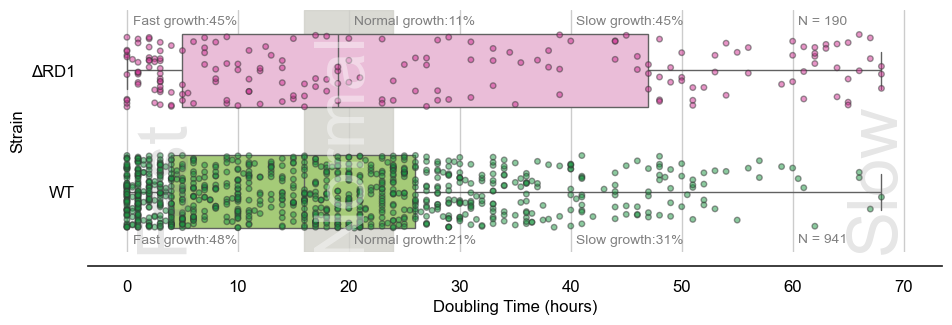

In [6]:
# Step 2: Plot the boxplot and stripplot (same as before)
f, ax = plt.subplots(figsize=(width_in, height_in/1.25))

sns.boxplot(
    data=subset_df, x="Doubling Times", y="Strain", hue="Strain", 
    whis=[0, 100], width=.6, palette=[expanded_piyg[1], expanded_piyg[-2]]
)

sns.stripplot(
    data=subset_df, x="Doubling Times", y="Strain", size=4, hue="Strain", 
    palette=[expanded_piyg[0], expanded_piyg[-1]], alpha=0.5,
    edgecolor='gray', linewidth=1, jitter=0.3,
)


# Step 4: Calculate and add count and percentage labels for each strain in each growth category
total_counts = subset_df.groupby(['Strain', 'Growth Category']).size()  # Count occurrences per strain and category
strain_totals = subset_df['Strain'].value_counts()  # Total counts per strain


for strain in subset_df['Strain'].unique():
    for category in labels:
        # Get the count for the current strain and category
        count = total_counts.get((strain, category), 0)
        # Calculate the percentage for this strain in this category
        percentage = (count / strain_totals[strain]) * 100
        # Add the count and percentage label on the plot
        ax.text(
            0.5 + labels.index(category)*20 , (-0.4 if strain == 'WT' else 1.4), # Adjust position based on strain
            f"{category} growth:{percentage:.0f}%", 
            color="gray", fontsize=10, va='center', ha='left'
        )

    ax.text(
            0.5 + (labels.index(category)+1)*20 , (-0.4 if strain == 'WT' else 1.4), # Adjust position based on strain
            f"N = {strain_totals[strain]}", 
            color="gray", fontsize=10, va='center', ha='left'
            )

# Step 5: Adjust y-limits to bring boxplots closer together
ax.set_ylim(-0.5, 1.5)  # Compresses the space between the two strains

# Add shaded regions for each growth category
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0., label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(bins[0] + 0.5, -0.4, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1] + 0.5, -0.4, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70 + 0.5, -0.4, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)


replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

# Final tweaks
ax.xaxis.grid(True)
sns.despine(offset=10, left=True)

plt.xlabel('Doubling Time (hours)')
# Save the figure
# plt.savefig(os.path.join(output_dir, 'wt_rd1_dt_unfiltered_growth_cats.pdf'), bbox_inches='tight',  dpi=314)
plt.show()


/tmp/ipykernel_306998/1037978102.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  growth_speed_counts = subset_df.groupby(['Strain', 'Growth Category']).size().unstack(fill_value=0)
/tmp/ipykernel_306998/1037978102.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rectangle((0, 0), bbox_w, bbox_h, color=expanded_piyg[1], edgecolor='none'),  # Color for the first category
/tmp/ipykernel_306998/1037978102.py:69: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rectangle((0, 0), bbox_w, bbox_h, color=expanded_piyg[-2], edgecolor='none'),  # Color for the second category
/tmp/ipykernel_306998/1037978102.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor prope

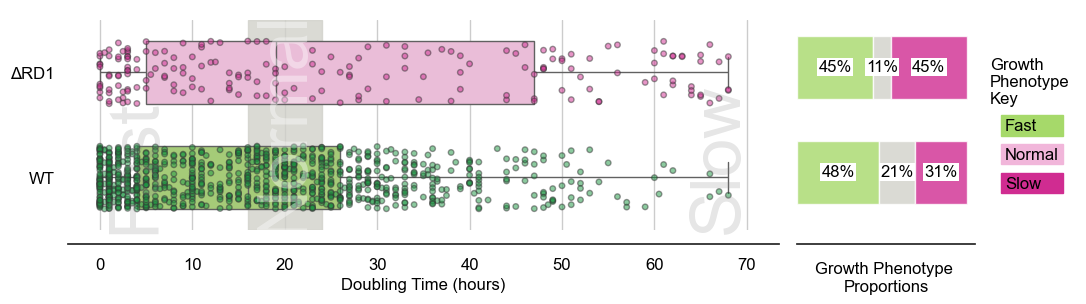

/tmp/ipykernel_306998/2345058125.py:75: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



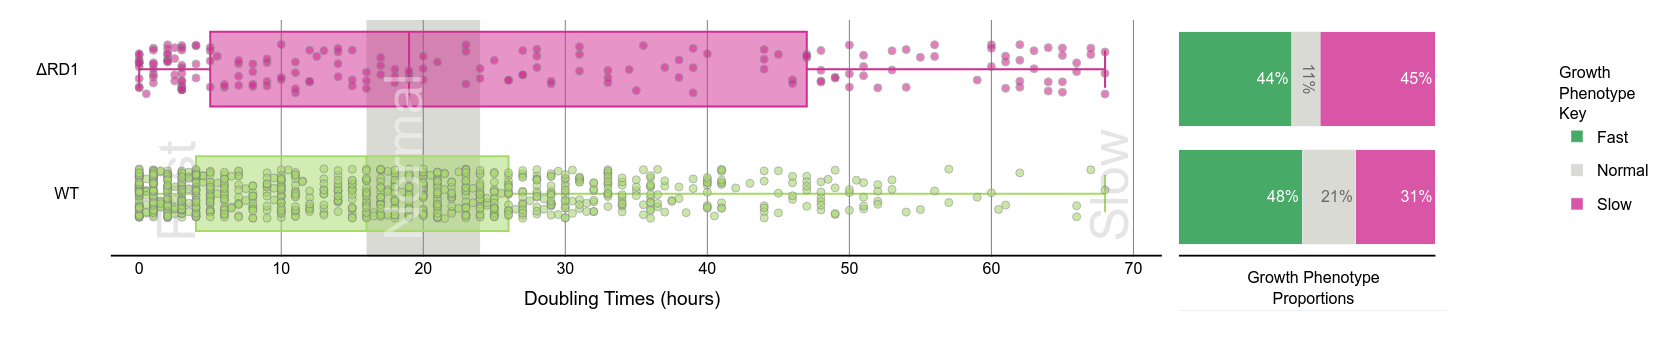

In [607]:
from dash import Dash, dcc, html, Input, Output

import math

def custom_round(value, precision):
    return round(value + 1e-10, precision)
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

def custom_round(value, precision):
    return round(value + 1e-10, precision)

# Create a subplot with two vertical sections and an additional row for the title
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.8, 0.2],
    row_heights=[0.95, 0.4],  # Add small row at bottom for title
    horizontal_spacing=0.01,
    vertical_spacing=0.01
)

# First section: Boxplots, stripplots, and shaded regions
for strain in subset_df['Strain'].unique():
    strain_data = subset_df[subset_df['Strain'] == strain]
    jitter = np.random.uniform(-0.2, 0.2, size=len(strain_data))
    strain_numeric = np.where(subset_df['Strain'].unique() == strain)[0][0]
    
    # Add boxplot trace
    fig.add_trace(go.Box(
        x=strain_data['Doubling Times'],
        y=[strain_numeric] * len(strain_data),
        name=strain,
        marker_color=colors[strain],
        hoverinfo='none',
        boxmean=False,
        orientation="h",
        width=0.6,
        boxpoints=False,
        showlegend=False
    ), row=1, col=1)
    
    # Add stripplot trace
    fig.add_trace(go.Scatter(
        x=strain_data['Doubling Times'],
        y=[strain_numeric] * len(strain_data)+ jitter,
        mode="markers",
        name=strain,
        marker=dict(color=colors[strain], size=14, opacity=0.6, line=dict(color='gray', width=1)),
        customdata=strain_data['Video Link'],
        hoverinfo="text",
        text=[
            f"<b>Doubling Time:</b> {x:.2f}<br><b>Strain:</b> {strain}<br>"
            for x in strain_data['Doubling Times']
        ],
        showlegend=False
    ), row=1, col=1)

# Add shaded regions
fig.add_vrect(x0=0, x1=bins[1], fillcolor=expanded_piyg[3], opacity=0, layer="below", line_width=0, row=1, col=1)
fig.add_vrect(x0=bins[1], x1=bins[2], fillcolor=expanded_piyg[3], opacity=0.8, layer="below", line_width=0, row=1, col=1)
fig.add_vrect(x0=bins[2], x1=70, fillcolor=expanded_piyg[3], opacity=0, layer="below", line_width=0, row=1, col=1)

# Add vertical text labels within each category region
fig.add_annotation(x=bins[0] + 0.5, y=-0.4, text='Fast', font=dict(size=52, color='gray'), opacity=0.2, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=bins[1] + 0.5, y=-0.4, text='Normal', font=dict(size=52, color='white'), opacity=0.4, 
                  xanchor='left', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)
fig.add_annotation(x=70 + 0.5, y=-0.4, text='Slow', font=dict(size=52, color='gray'), opacity=0.2, 
                  xanchor='right', yanchor='bottom', showarrow=False, textangle=-90, row=1, col=1)

# Calculate and add growth speed percentages
growth_speed_counts = subset_df.groupby(['Strain', 'Growth Category']).size().unstack(fill_value=0)
growth_speed_percentages = growth_speed_counts.div(growth_speed_counts.sum(axis=1), axis=0).reindex(index=subset_df['Strain'].unique())

# Add stacked bar chart
for i, strain in enumerate(subset_df['Strain'].unique()):
    percentages = growth_speed_percentages.iloc[i]
    rounded_percentages = [custom_round(p, 2) for p in percentages]
    
    total = sum(rounded_percentages)
    if total != 1:
        diff = 1 - total
        max_idx = rounded_percentages.index(max(rounded_percentages))
        rounded_percentages[max_idx] += diff
    
    for j, (category, percentage) in enumerate(zip(growth_speed_percentages.columns, rounded_percentages)):
        fig.add_trace(go.Bar(
            x=[percentage],
            y=[strain],
            orientation='h',
            marker_color=colors[category],
            opacity=0.8,
            showlegend=i==0,
            legendgroup=category,
            name=category,
            text=[f"{round(percentage * 100)}%"],
            textposition='inside',
            hoverinfo='text',
            hovertext=[f"{strain}<br>{category}: {round(percentage * 100)}%"]
        ), row=1, col=2)

# Add title text as a bar trace in the bottom row
fig.add_trace(go.Bar(
    x=[1],
    y=[-0],
    width=30,
    marker_color='rgba(0,0,0,0)',  # Transparent
    text=['Growth Phenotype<br>Proportions'],
    textposition='outside',
    textfont=dict(size=16, color='black'),
    showlegend=False,
    hoverinfo='none'
), row=2, col=2)

# Define common font settings
font_settings = dict(
    family='Helvetica, Arial, sans-serif',
    size=16, 
    color='black'
)

# Update layout
fig.update_layout(
    barmode='stack',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=965,
    margin=dict(b=0, t=20),  # Reduced bottom margin
    font=font_settings,
    legend=dict(
        title='Growth<br>Phenotype<br>Key',
        orientation='v',
        yanchor='middle', y=0.65,
        xanchor='right', x=1.15,
        title_side='top',
        title_font_size=16,
        font=dict(size=16)
    ),
    showlegend=True
)

# Update axes configurations for main plots
axes_updates = {
    (1,1): dict(
        x=dict(
            visible=True,
            tickmode='linear',
            tick0=0,
            dtick=10,
            gridcolor='gray',
            gridwidth=1,
            title_text='Doubling Times (hours)'
        ),
        y=dict(
            ticktext=["WT", "ΔRD1"],
            tickvals=[0, 1]
        )
    ),
    (1,2): dict(
        x=dict(visible=False),
        y=dict(
            ticktext=[],
            tickvals=[]
        )
    )
}

# Apply axes updates
for (row, col), settings in axes_updates.items():
    if 'x' in settings:
        fig.update_xaxes(**settings['x'], row=row, col=col)
    if 'y' in settings:
        fig.update_yaxes(**settings['y'], row=row, col=col)

# Hide axes for the bottom row
fig.update_xaxes(visible=False, row=2, col=1)
fig.update_xaxes(visible=False, row=2, col=2)
fig.update_yaxes(visible=False, row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=2)

# Add horizontal lines
for col, x_range in [(1, (-2, 72)), (2, (0, 1))]:
    fig.add_shape(
        type='line',
        x0=x_range[0], x1=x_range[1],
        y0=-0.5, y1=-0.5,
        line=dict(color='black', width=2),
        row=1, col=col
    )


fig.show()

boxplot = fig

In [331]:
html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
        <style>
            .container {{
                width: 80%;
                margin: 0 auto;
            }}
            #plot {{
                width: 100%;
                height: 60vh;
            }}
            .hover-popup {{
                position: absolute;
                background-color: white;
                border: 2px solid white;
                padding: 5px;
                z-index: 1000;
                display: none;
                box-shadow: 0 2px 10px rgba(0,0,0,0.1);
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <div id="plot"></div>
            <div id="hover-popup" class="hover-popup">
                <video id="popup-video" style="width: 400px; height: 400px; 
                       object-fit: cover; object-position: center top;" 
                       autoplay loop muted playsinline></video>
            </div>
        </div>

        <script>
            // Load the Plotly figure
            const figure = {fig.to_json()};
            
            // Initialize the plot
            Plotly.newPlot('plot', figure.data, figure.layout);
            
            const hoverPopup = document.getElementById('hover-popup');
            const popupVideo = document.getElementById('popup-video');
            
            // Add hover event listener for plot
            document.getElementById('plot').on('plotly_hover', function(eventData) {{
                const point = eventData.points[0];
                const videoUrl = point.customdata;
                
                if (videoUrl) {{
                    // Update video source and show popup
                    popupVideo.src = videoUrl;
                    hoverPopup.style.display = 'block';
                    
                    // Position the popup near the cursor
                    const hoverWidth = hoverPopup.offsetWidth;
                    hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                    hoverPopup.style.top = `${{eventData.event.clientY + 20}}px`;
                }}
            }});
            
            // Hide popup on unhover
            document.getElementById('plot').on('plotly_unhover', function() {{
                hoverPopup.style.display = 'none';
                popupVideo.pause();
            }});
        </script>
    </body>
    </html>
"""
# Save the plot to an HTML file with added video functionality
output_file = "../interactive_plots/F2.html"
# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)
print(f"Interactive plot with video hover saved to {output_file}")

# After your existing code that saves the file:
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video hover saved to ../interactive_plots/F2.html


True

### Adding single-cell graphs above it

In [434]:
def save_interactive_growth_curve(fig, output_file):
    """
    Save a Plotly growth curve figure as an HTML file with image popup functionality.
    
    Args:
        fig: Plotly figure object with customdata containing image URLs
        output_file: Path to save the HTML file
    """
    
    html_template = f"""
                    <!DOCTYPE html>
                    <html>
                    <head>
                        <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
                        <style>
                            .container {{
                                width: 80%;
                                margin: 0 auto;
                            }}
                            #plot {{
                                width: 100%;
                                height: 80vh;
                            }}
                            .hover-content {{
                                position: absolute;
                                background-color: white;
                                border: 2px solid white;
                                padding: 5px;
                                z-index: 1000;
                                display: flex;
                                align-items: center;
                                gap: 10px;
                                box-shadow: 0 2px 10px rgba(0,0,0,0.1);
                            }}
                            .hover-content img {{
                                width: 300px;
                                height: auto;
                            }}
                        </style>
                    </head>
                    <body>
                        <div class="container">
                            <div id="plot"></div>
                        </div>
                        <script>
                            // Load the Plotly figure
                            const figure = {fig.to_json()};
                            
                            // Initialize the plot
                            Plotly.newPlot('plot', figure.data, figure.layout);
                            
                            // Add hover event listener
                            document.getElementById('plot').on('plotly_hover', function(eventData) {{
                                const point = eventData.points[0];
                                const imageUrl = point.customdata;
                                
                                if (imageUrl) {{
                                    // Create new hover content
                                    const hoverContent = document.createElement('div');
                                    hoverContent.className = 'hover-content';
                                    hoverContent.innerHTML = `<img src="${{imageUrl}}">`;
                                    document.body.appendChild(hoverContent);
                                    
                                    // Position to the left of the cursor
                                    const hoverWidth = hoverContent.offsetWidth;
                                    hoverContent.style.left = `${{eventData.event.clientX - hoverWidth - 10}}px`;
                                    hoverContent.style.top = `${{eventData.event.clientY - 50}}px`;
                                    
                                    // Remove on unhover
                                    document.getElementById('plot').on('plotly_unhover', function() {{
                                        hoverContent.remove();
                                    }});
                                }}
                            }});
                        </script>
                    </body>
                    </html>
                    """

    # Write the HTML file
    with open(output_file, "w") as f:
        f.write(html_template)
    print(f"Interactive growth curve saved to {output_file}")

200

In [284]:
def add_grid_lines(fig, time_points, populations, x_range=[0, 80], y_range=[0, 300]):
    """Add doubling time grid lines to the figure"""
    for time, population in zip(time_points, populations):
        # Vertical and horizontal lines for each doubling point
        shapes = [
            # Vertical line
            dict(
                type='line',
                x0=time, x1=time,
                y0=y_range[0], y1=y_range[1],
                line=dict(color='gray', width=1, dash='dash'),
                opacity=0.5
            ),
            # Horizontal line
            dict(
                type='line',
                x0=x_range[0], x1=x_range[1],
                y0=population, y1=population,
                line=dict(color='gray', width=1, dash='dash'),
                opacity=0.5
            )
        ]
        fig.update_layout(shapes=list(fig.layout.shapes) + shapes)

def add_axis_lines(fig, x_range=[-2, 80], y_range=[0, 300]):
    """Add solid black axis lines to the figure with offset"""
    axis_shapes = [
        # Y-axis (offset)
        dict(
            type="line",
            xref="x", yref="y",
            x0=-2,  # Fixed position for y-axis
            x1=-2,
            y0=0,  # Extended below to match offset
            y1=300,
            line=dict(color="black", width=2, dash='solid')
        ),
        # X-axis (offset)
        dict(
            type="line",
            xref="x", yref="y",
            x0=0,  # Extended left to match offset
            x1=80,
            y0=-10,  # Fixed position for x-axis
            y1=-10,
            line=dict(color="black", width=2, dash='solid')
        )
    ]
    fig.update_layout(shapes=list(fig.layout.shapes) + axis_shapes)

In [462]:
unique_IDs = list(reversed(unique_IDs))

In [608]:
# Create the HTML template
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        /* Main layout containers */
        .main-container {{
            width: 1000px;
            margin: 0 auto;
            padding: 20px;
        }}
        
        /* Growth curves section */
        .pairs-container {{
            display: flex;
            flex-direction: column;
            margin-bottom: 40px;
        }}
        
        .pair {{
            display: flex;
            gap: 40px;
            align-items: center;
        }}
        
        /* Images */
        .figure-image {{
            flex: 0 0 auto;
            width: 50%;
            position: relative;
        }}
        
        .figure-image img {{
            width: 100%;
            height: auto;
            cursor: pointer;
        }}
        
        /* Plots */
        .growth-plot {{
            flex: 1;
            min-width: 0;
        }}
        
        /* Boxplot section */
        .boxplot-section {{
            display: flex;
            gap: 0px;
            align-items: flex-start;

        }}
        
        .caption-image {{
            width: 35px;
            flex: 0 0 auto;
        }}
        
        #boxplot {{
            flex: 1;
        }}
        
        /* Hover effects */
        .hover-content, .hover-popup, .video-hover {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        
        .hover-content {{
            display: flex;
            align-items: center;
        }}
        
        .hover-content img {{
            width: 300px;
            height: auto;
        }}
        
        .hover-popup, .video-hover {{
            display: none;
        }}
        
    </style>
</head>
<body>
    <div class="main-container">
        <div class="pairs-container">
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S2.mp4">
                    <img src="../images/Figure_2_1.png" alt="Figure 1">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-1" class="growth-plot"></div>
            </div>
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S3.mp4">
                    <img src="../images/Figure_2_2.png" alt="Figure 2">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-2" class="growth-plot"></div>
            </div>
            <div class="pair">
                <div class="figure-image" data-video="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Movie S4.mp4">
                    <img src="../images/Figure_2_3.png" alt="Figure 3">
                    <div class="video-hover">
                        <video style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                               autoplay loop muted playsinline></video>
                    </div>
                </div>
                <div id="growth-plot-3" class="growth-plot"></div>
            </div>
        </div>        
        <div class="boxplot-section">
            <div class="caption-image">
                <img src="../images/D_caption.png" style="width: 100%; height: 80%; object-fit: cover; object-position: top; margin-left: -10px;" alt="Caption">
            </div>
            <div id="boxplot"></div>
            <div id="hover-popup" class="hover-popup">
                <video id="popup-video" style="width: 400px; height: 400px; object-fit: cover; object-position: left top;" 
                       autoplay loop muted playsinline></video>
            </div>
        </div>
    </div>
    
    <script>
        // Growth curves plots
        const growthFig1 = {sc_figs[0].to_json()};
        const growthFig2 = {sc_figs[1].to_json()};
        const growthFig3 = {sc_figs[2].to_json()};
        const boxplotFig = {boxplot.to_json()};
        
        // Initialize all plots with minimal margins
        const layout1 = {{...growthFig1.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout2 = {{...growthFig2.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        const layout3 = {{...growthFig3.layout, margin: {{t: 50, b: 0, l: 50, r: 50}}}};
        
        Plotly.newPlot('growth-plot-1', growthFig1.data, layout1);
        Plotly.newPlot('growth-plot-2', growthFig2.data, layout2);
        Plotly.newPlot('growth-plot-3', growthFig3.data, layout3);
        Plotly.newPlot('boxplot', boxplotFig.data, boxplotFig.layout);
        
        // Setup hover for growth plots
        ['growth-plot-1', 'growth-plot-2', 'growth-plot-3'].forEach(plotId => {{
            const plotDiv = document.getElementById(plotId);
            plotDiv.style.position = 'relative';  // Make plot div a positioning context
            
            plotDiv.on('plotly_hover', function(eventData) {{
                const point = eventData.points[0];
                const imageUrl = point.customdata;
                
                if (imageUrl) {{
                    const hoverContent = document.createElement('div');
                    hoverContent.className = 'hover-content';
                    hoverContent.innerHTML = `<img src="${{imageUrl}}">`;
                    plotDiv.appendChild(hoverContent);  // Append to plot instead of body
                    
                    const hoverWidth = hoverContent.offsetWidth;
                    hoverContent.style.left = `${{eventData.event.clientX - plotDiv.getBoundingClientRect().left - hoverWidth - 10}}px`;
                    hoverContent.style.top = `${{eventData.event.clientY - plotDiv.getBoundingClientRect().top + 35}}px`;
                    
                    this.on('plotly_unhover', function() {{
                        hoverContent.remove();
                    }});
                }}
            }});
        }});

        // Setup hover for images
        document.querySelectorAll('.figure-image').forEach(container => {{
            const videoHover = container.querySelector('.video-hover');
            const video = videoHover.querySelector('video');
            const videoUrl = container.dataset.video;
            
            container.addEventListener('mouseenter', (event) => {{
                if (videoUrl) {{
                    video.src = videoUrl;
                    videoHover.style.display = 'block';
                    
                    // Position video hover to the right of the image
                    const containerRect = container.getBoundingClientRect();
                    videoHover.style.left = `${{containerRect.width + 20}}px`;  // 20px gap
                    videoHover.style.top = `${{(containerRect.height - videoHover.offsetHeight) / 2}}px`;
                }}
            }});
            
            container.addEventListener('mouseleave', () => {{
                videoHover.style.display = 'none';
                video.pause();
            }});
        }});
        
        // Setup hover for boxplot
        const hoverPopup = document.getElementById('hover-popup');
        const popupVideo = document.getElementById('popup-video');
        
        document.getElementById('boxplot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoUrl = point.customdata;
            
            if (videoUrl) {{
                popupVideo.src = videoUrl;
                hoverPopup.style.display = 'block';
                
                const hoverWidth = hoverPopup.offsetWidth;
                const hoverHeight = hoverPopup.offsetHeight;
                hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth}}px`;  // Align right edge
                hoverPopup.style.top = `${{eventData.event.clientY + hoverHeight}}px`;   // Align bottom edge
            }}
        }});
        
        document.getElementById('boxplot').on('plotly_unhover', function() {{
            hoverPopup.style.display = 'none';
            popupVideo.pause();
        }});
    </script>
</body>
</html>
"""

# Save and open the HTML file
with open('../interactive_plots/F2.html', 'w') as f:
    f.write(html_template)

webbrowser.open('file://' + os.path.realpath('../interactive_plots/F2.html'))

True

In [ ]:
                    const hoverWidth = hoverPopup.offsetWidth;
                    hoverPopup.style.left = `${{eventData.event.clientX - hoverWidth/2}}px`;
                    hoverPopup.style.top = `${{eventData.event.clientY}}px`;